# Kommentar-Themen Vergleich

Dieses Notebook wertet die berechneten Kommentar-Themen aus.


In [3]:
from pathlib import Path
from math import sqrt
import textwrap

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.family"] = "DejaVu Sans"

COLOR_VI = "#2A9D8F"
COLOR_RI = "#B85C7A"
COLOR_INK = "#24323A"
COLOR_MUTED = "#667085"
COLOR_GRID = "#E6E8EC"
PALETTE = {"VI": COLOR_VI, "RI": COLOR_RI}
TYPE_LABELS = {"KI": "VI", "Real": "RI", "VI": "VI", "RI": "RI"}
TYPE_NOTE = "VI = AI-generierte Videos; RI = reale Videos"


def wrap_label(value, width=22):
    return "\n".join(textwrap.wrap(str(value), width=width, break_long_words=False))


def prettify_topic_labels(series, width=24):
    return series.astype(str).map(lambda s: wrap_label(s.replace(" | ", " / "), width=width))


def style_axis(ax):
    ax.grid(True, axis="y", color=COLOR_GRID)
    ax.grid(False, axis="x")
    ax.tick_params(colors=COLOR_INK)
    ax.xaxis.label.set_color(COLOR_INK)
    ax.yaxis.label.set_color(COLOR_INK)
    sns.despine(ax=ax)


def add_caption(fig, text, y=0.012):
    fig.text(0.01, y, text, ha="left", va="bottom", fontsize=9.0, color=COLOR_MUTED)


def cohens_d(group_a, group_b):
    a = pd.Series(group_a).dropna().to_numpy()
    b = pd.Series(group_b).dropna().to_numpy()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled_var = ((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2)
    return (a.mean() - b.mean()) / sqrt(pooled_var) if pooled_var > 0 else np.nan


def p_text(p_value):
    return "signifikant" if pd.notna(p_value) and p_value < 0.05 else "nicht signifikant"


def d_interpretation(d_value):
    if pd.isna(d_value):
        return "nicht bestimmbar"
    abs_d = abs(d_value)
    if abs_d < 0.2:
        return "vernachlässigbar klein"
    if abs_d < 0.5:
        return "klein"
    if abs_d < 0.8:
        return "mittel"
    return "groß"


In [4]:
BASE_DIR = Path.cwd().resolve().parents[1]
COMMENT_RESULTS_CSV = BASE_DIR / "comments" / "results" / "04_comment_topics_results.csv"
VIDEO_LEVEL_CSV = BASE_DIR / "comments" / "results" / "04_comment_topics_video_level.csv"
TOPIC_ENGAGEMENT_CSV = BASE_DIR / "comments" / "results" / "04_comment_topics_engagement_relations.csv"
TOPIC_KEYWORDS_CSV = BASE_DIR / "comments" / "results" / "04_comment_topics_keywords.csv"



In [5]:
comments_df = pd.read_csv(COMMENT_RESULTS_CSV)
video_level_df = pd.read_csv(VIDEO_LEVEL_CSV)
topic_engagement_df = pd.read_csv(TOPIC_ENGAGEMENT_CSV)
topic_keywords_df = pd.read_csv(TOPIC_KEYWORDS_CSV)

required_comment_cols = {"Typ", "comment_id", "topic_label"}
required_video_cols = {"video_id", "Typ", "video_engagement_rate", "comment_count", "topic_unique_labels", "dominant_topic_label"}
missing_comment = required_comment_cols - set(comments_df.columns)
missing_video = required_video_cols - set(video_level_df.columns)
if missing_comment or missing_video:
    raise ValueError(
        "Die exportierten Topic-Dateien passen nicht zur aktuellen Comparison-Logik. "
        f"Fehlende Kommentarspalten: {sorted(missing_comment)} | Fehlende Video-Spalten: {sorted(missing_video)}. "
        "Bitte zuerst 04_comment_topic_analysis.ipynb neu ausführen."
    )

comments_df["Typ_plot"] = comments_df["Typ"].map(TYPE_LABELS).fillna(comments_df["Typ"])
video_level_df["Typ_plot"] = video_level_df["Typ"].map(TYPE_LABELS).fillna(video_level_df["Typ"])

label_share_df = comments_df.groupby(["Typ_plot", "topic_label"]).size().rename("Anzahl").reset_index()
label_share_df["Anteil_prozent"] = label_share_df.groupby("Typ_plot")["Anzahl"].transform(lambda s: 100 * s / s.sum())
ct = pd.crosstab(comments_df["Typ_plot"], comments_df["topic_label"])
chi2, chi2_p, chi2_df, _ = chi2_contingency(ct)

video_group_summary = (
    video_level_df.groupby("Typ_plot")
    .agg(
        Videos=("video_id", "count"),
        Kommentare_M=("comment_count", "mean"),
        topic_unique_labels_M=("topic_unique_labels", "mean"),
        topic_unique_labels_Md=("topic_unique_labels", "median"),
    )
    .round(4)
    .reset_index()
    .rename(columns={"Typ_plot": "Typ"})
)
vi_v = video_level_df.loc[video_level_df["Typ_plot"] == "VI", "topic_unique_labels"]
ri_v = video_level_df.loc[video_level_df["Typ_plot"] == "RI", "topic_unique_labels"]
video_u, video_p = mannwhitneyu(vi_v, ri_v, alternative="two-sided")
video_d = cohens_d(vi_v, ri_v)

video_corr_df = video_level_df.dropna(subset=["video_engagement_rate"]).copy()
eligible_topic_groups = [group["video_engagement_rate"].to_numpy() for _, group in video_corr_df.groupby("dominant_topic_label") if len(group) >= 2]
if len(eligible_topic_groups) >= 2:
    dominant_topic_h, dominant_topic_p = kruskal(*eligible_topic_groups)
else:
    dominant_topic_h, dominant_topic_p = np.nan, np.nan

if "comment_share" not in topic_keywords_df.columns:
    total_comments = topic_keywords_df["comment_count"].sum()
    topic_keywords_df["comment_share"] = np.where(
        total_comments > 0,
        topic_keywords_df["comment_count"] / total_comments,
        np.nan,
    )

topic_keywords_preview = topic_keywords_df[["topic_id", "topic_label", "keywords", "comment_count", "comment_share"]].head(12).copy()
video_group_summary_display = video_group_summary.copy()
engagement_preview = topic_engagement_df.head(12).copy()

display(topic_keywords_preview)
display(video_group_summary_display)
display(engagement_preview)


,topic_id,topic_label,keywords,comment_count,comment_share
0,3,health | sleep | worst,"health, sleep, worst, influencers, pain, politics",3635,0.111312
1,11,detroit | slay | twerk,"detroit, slay, twerk, connor, shane, agreed",3259,0.099798
2,4,pink | jacket | noodle,"pink, jacket, noodle, shade, song, kpop",2738,0.083844
3,0,gay | animated | steal,"gay, animated, steal, sleep, havent seen, existed",2659,0.081425
4,7,robot | expect | song,"robot, expect, song, kpop, caption, crying",2329,0.071319
5,12,notary | pump | mall,"notary, pump, mall, gas, city, places",2326,0.071227
6,5,almond | pain | lyme,"almond, pain, lyme, sugar, tried, chronic",2174,0.066573
7,8,acne | masks | mask,"acne, masks, mask, children, sephora, pimple",2110,0.064613
8,1,song | excited | interested,"song, excited, interested, collab, jewelry, de...",1871,0.057294
9,14,america | europe | world country,"america, europe, world country, germany, irela...",1827,0.055947


,Typ,Videos,Kommentare_M,topic_unique_labels_M,topic_unique_labels_Md
0,RI,640,28.2688,4.4000,4.0
1,VI,238,61.1933,5.7647,5.0


,topic_id,topic_label,rho,p,signifikant,videos_n
0,4,pink | jacket | noodle,-0.198170,7.325362e-05,True,395
1,8,acne | masks | mask,-0.203079,1.689926e-02,True,138
2,5,almond | pain | lyme,-0.227955,6.394372e-05,True,302
3,11,detroit | slay | twerk,-0.251074,4.295108e-07,True,395
4,10,philippines | notary | world country,-0.284508,3.527196e-02,True,55
5,6,robot | sophia | polar,-0.297851,2.997948e-05,True,190
6,0,gay | animated | steal,-0.299178,5.352457e-08,True,318
7,13,cgi | animated | edited,-0.386118,7.585986e-07,True,154
8,14,america | europe | world country,-0.396298,1.736554e-04,True,85
9,2,robot | cgi | generated,-0.434378,1.136879e-07,True,137


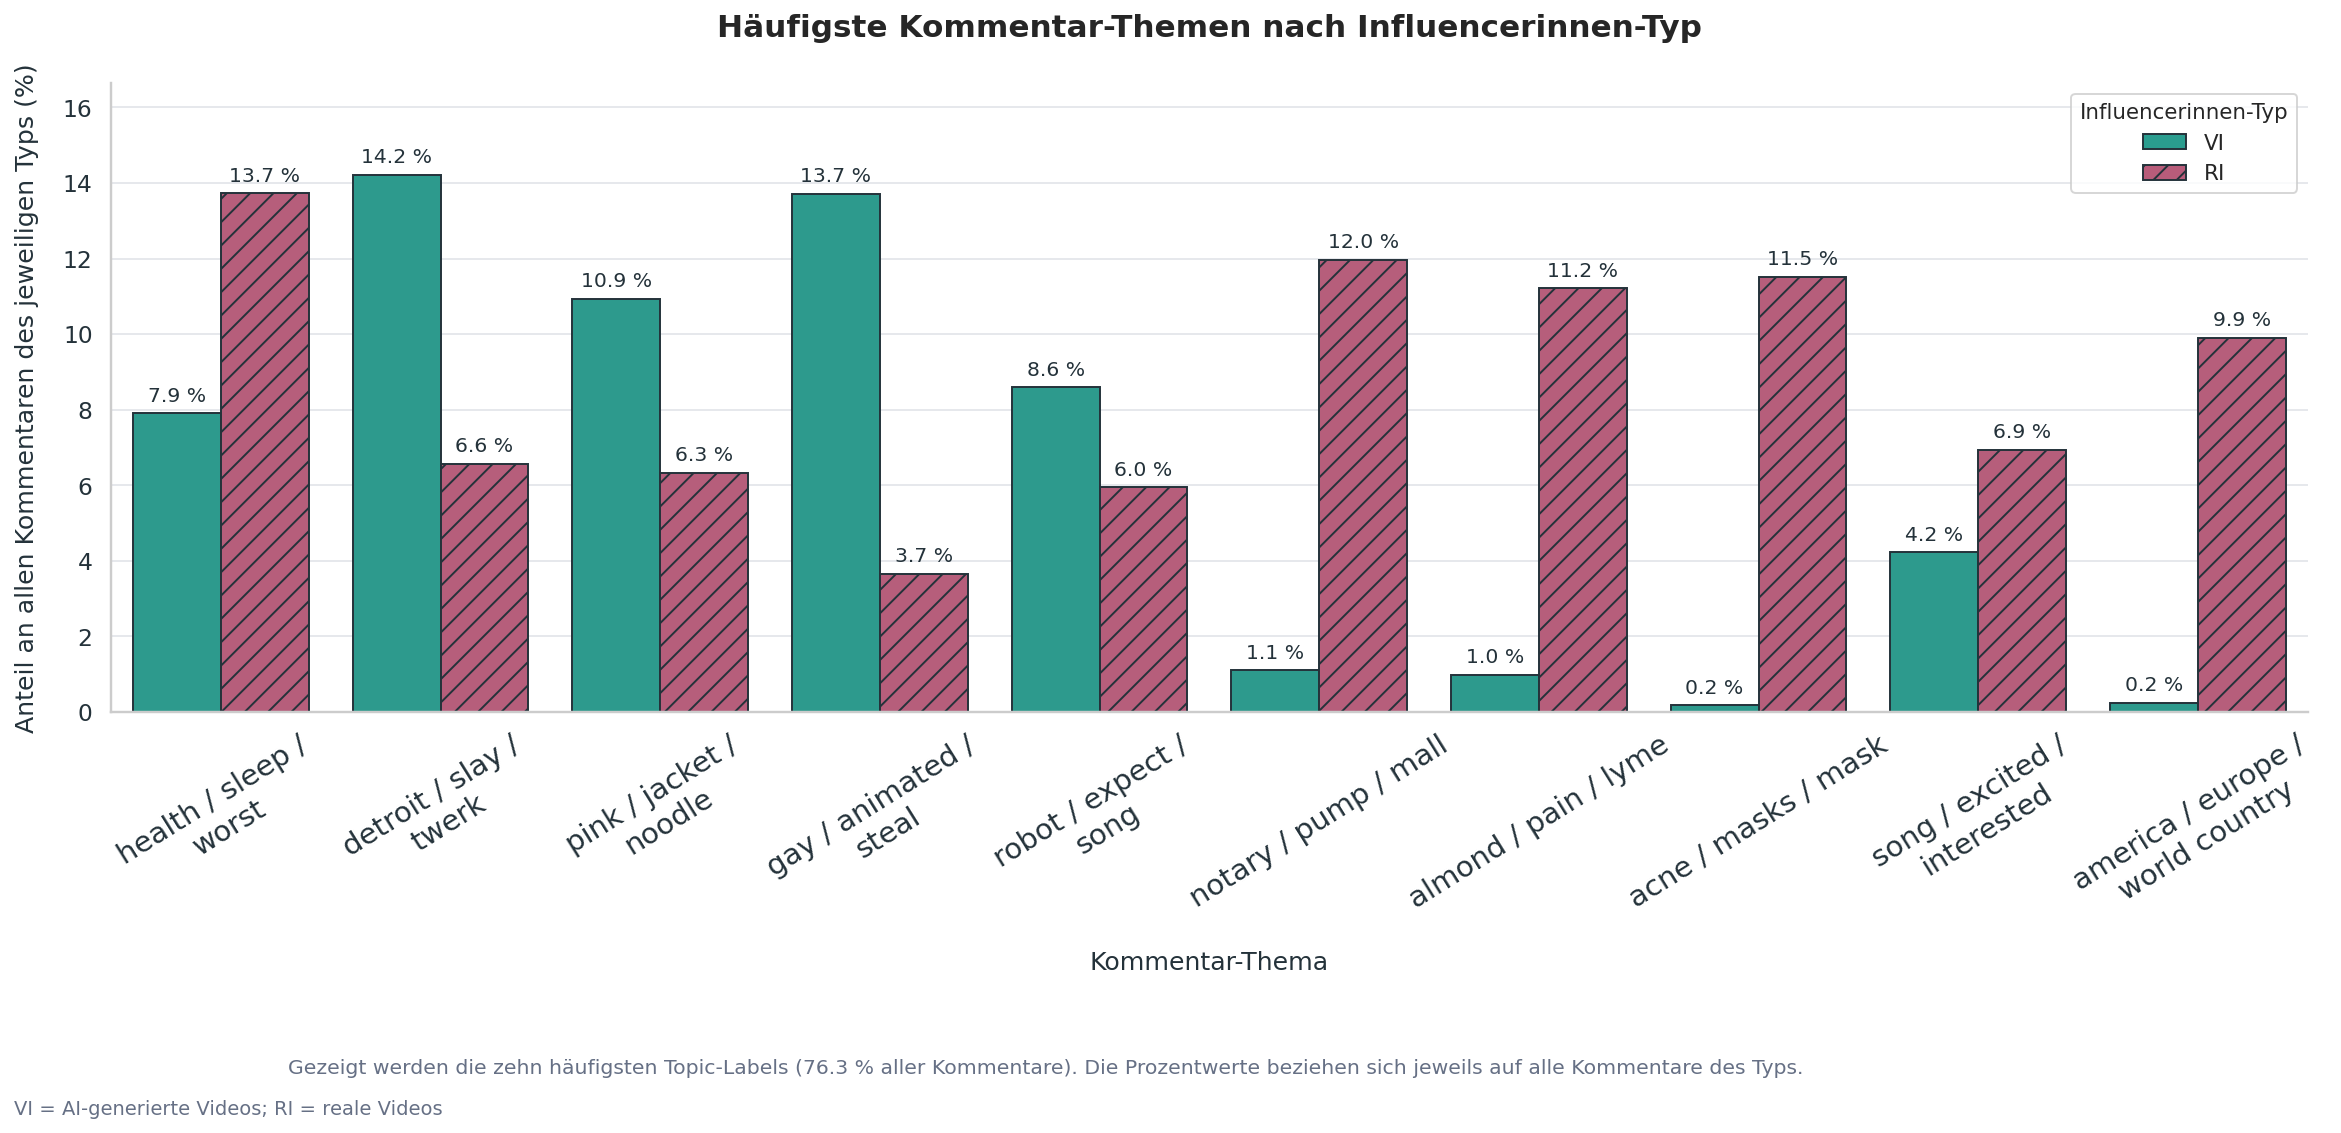

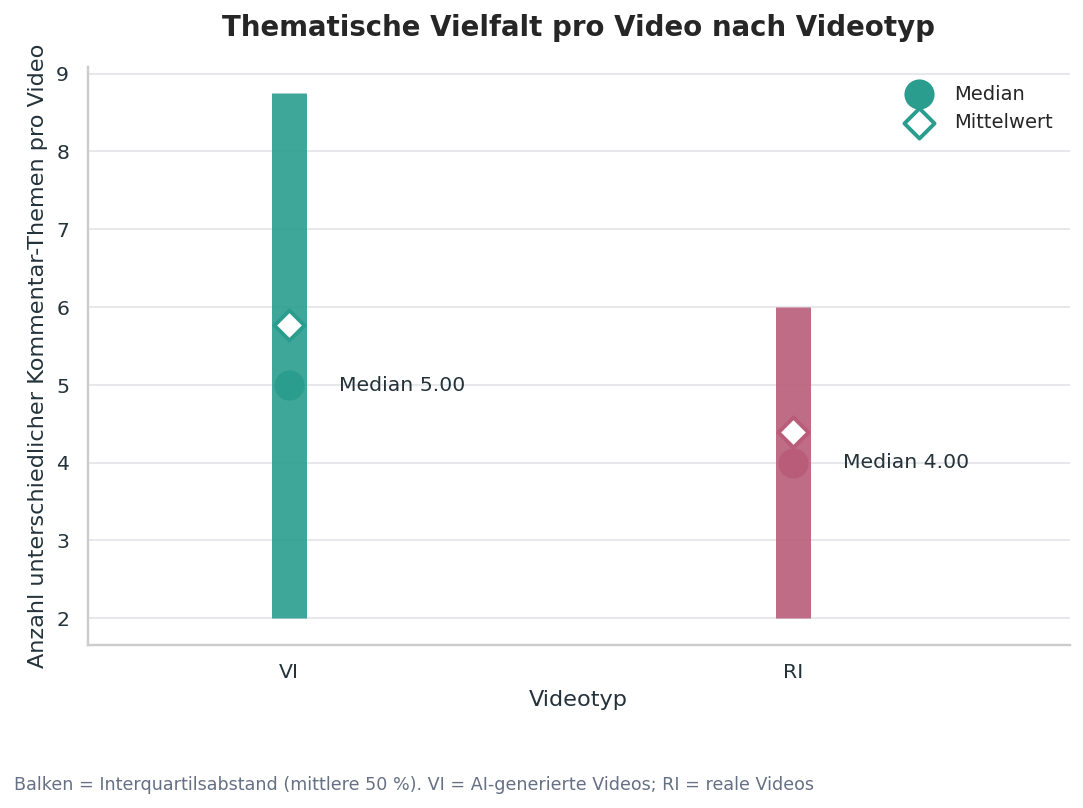

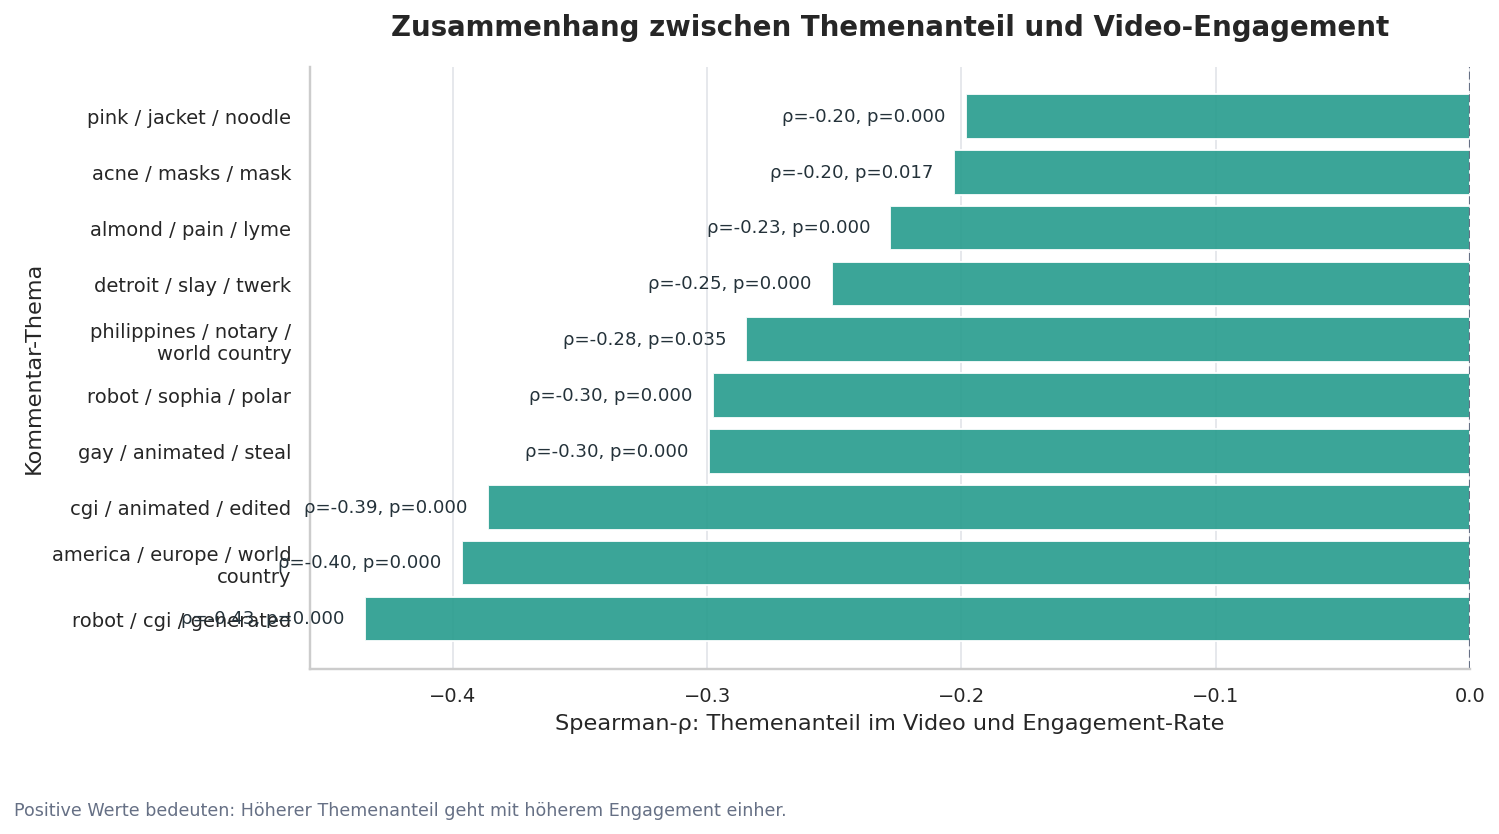

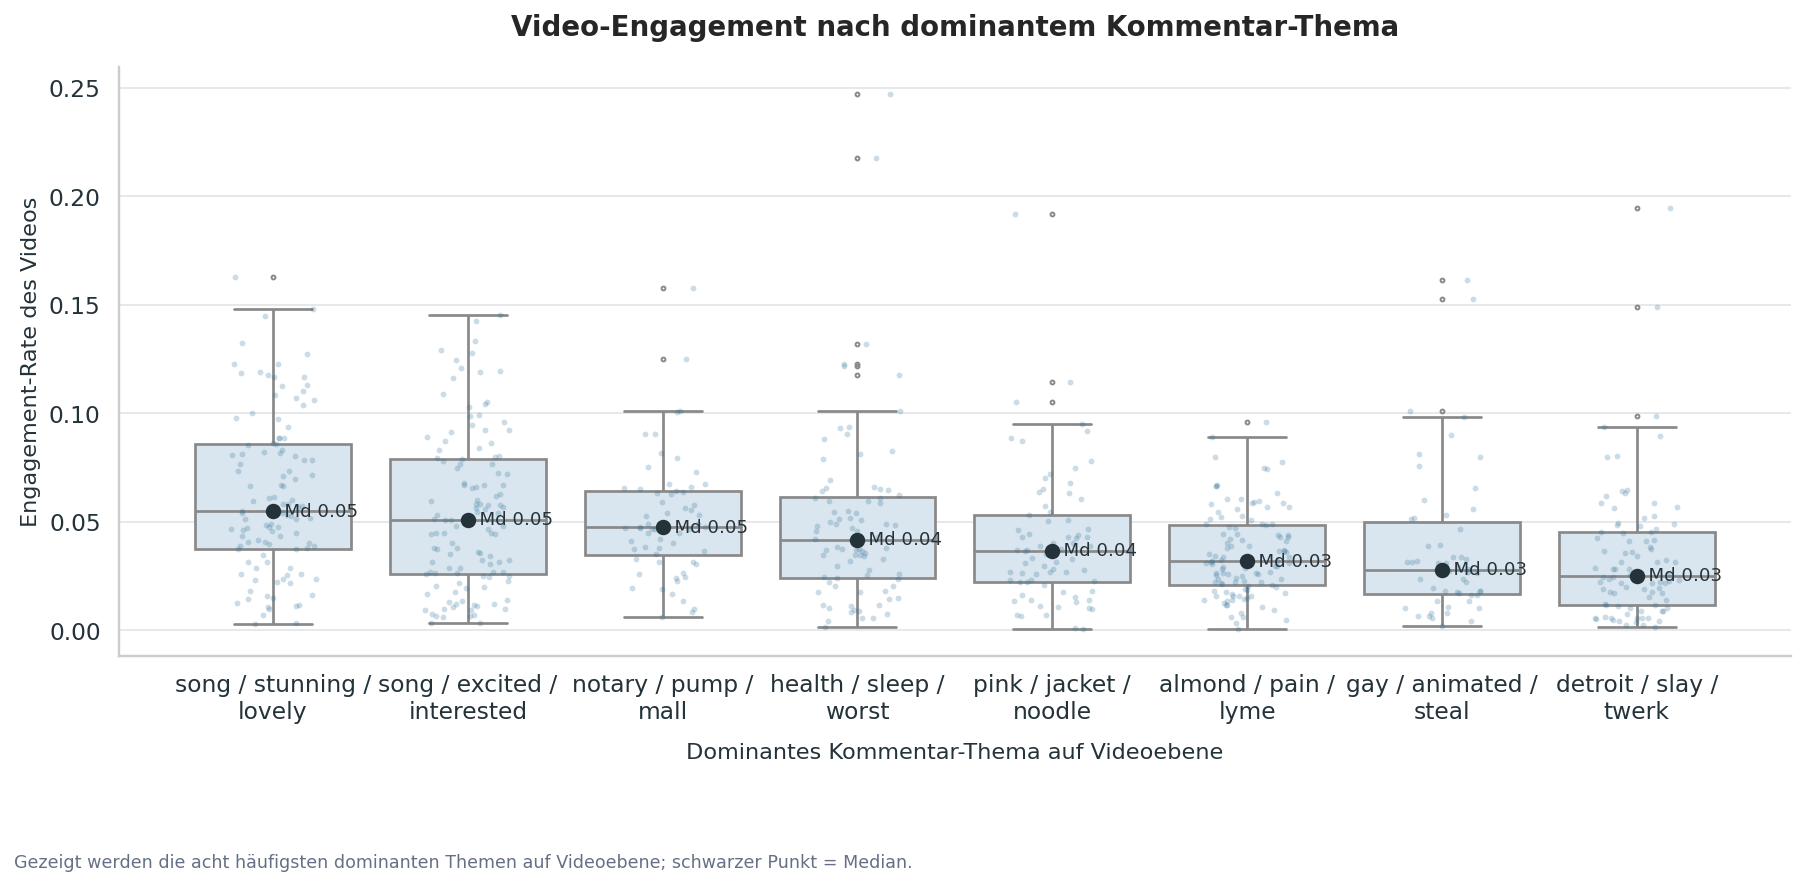

In [11]:
plot_df = label_share_df.copy()
top_topics = plot_df.groupby("topic_label")["Anzahl"].sum().nlargest(10).index
plot_df = plot_df[plot_df["topic_label"].isin(top_topics)].copy()
plot_df["topic_label_wrapped"] = prettify_topic_labels(plot_df["topic_label"], width=20)
order_wrapped = (
    plot_df.groupby(["topic_label", "topic_label_wrapped"])["Anzahl"].sum()
    .sort_values(ascending=False)
    .reset_index()["topic_label_wrapped"]
)

coverage = 100 * comments_df["topic_label"].isin(top_topics).mean()

fig, ax = plt.subplots(figsize=(17.0, 8.5))
fig.patch.set_facecolor("white")
sns.barplot(
    data=plot_df,
    x="topic_label_wrapped",
    y="Anteil_prozent",
    hue="Typ_plot",
    hue_order=["VI", "RI"],
    order=order_wrapped,
    palette=PALETTE,
    saturation=0.95,
    edgecolor=COLOR_INK,
    linewidth=1.0,
    ax=ax,
)
for container, hatch in zip(ax.containers, ["", "//"]):
    for bar in container:
        bar.set_hatch(hatch)
    ax.bar_label(container, fmt="%.1f %%", padding=4, fontsize=10.5, color=COLOR_INK)

ax.set_ylim(0, plot_df["Anteil_prozent"].max() * 1.17)
ax.set_title("Häufigste Kommentar-Themen nach Influencerinnen-Typ", fontsize=16, fontweight="semibold", pad=24)
ax.set_xlabel("Kommentar-Thema", fontsize=13, labelpad=14)
ax.set_ylabel("Anteil an allen Kommentaren des jeweiligen Typs (%)", fontsize=13, labelpad=12)
ax.tick_params(axis="x", rotation=32, labelsize=15)
ax.tick_params(axis="y", labelsize=12)
topic_legend = [
    Patch(facecolor=COLOR_VI, edgecolor=COLOR_INK, label="VI"),
    Patch(facecolor=COLOR_RI, edgecolor=COLOR_INK, hatch="//", label="RI"),
]
ax.legend(handles=topic_legend, title="Influencerinnen-Typ", frameon=True, fontsize=11, title_fontsize=11, loc="upper right")
style_axis(ax)
fig.text(
    0.125,
    0.045,
    f"Gezeigt werden die zehn häufigsten Topic-Labels ({coverage:.1f} % aller Kommentare). Die Prozentwerte beziehen sich jeweils auf alle Kommentare des Typs.",
    ha="left",
    va="bottom",
    fontsize=10.5,
    color=COLOR_MUTED,
)
fig.text(0.01, 0.01, TYPE_NOTE, ha="left", va="bottom", fontsize=10, color=COLOR_MUTED)
plt.tight_layout(rect=(0, 0.11, 1, 0.96))
plt.show()

summary_plot_df = (
    video_level_df.groupby("Typ_plot")["topic_unique_labels"]
    .agg(Q1=lambda s: s.quantile(0.25), Median="median", Q3=lambda s: s.quantile(0.75), Mittelwert="mean")
    .reindex(["VI", "RI"])
    .reset_index()
)
fig, ax = plt.subplots(figsize=(7.8, 6.2))
fig.patch.set_facecolor("white")
for x, row in enumerate(summary_plot_df.to_dict("records")):
    ax.vlines(x, row["Q1"], row["Q3"], color=PALETTE[row["Typ_plot"]], linewidth=18, alpha=0.90)
    ax.scatter(x, row["Median"], color=PALETTE[row["Typ_plot"]], s=210, zorder=3, label="Median" if x == 0 else None)
    ax.scatter(x, row["Mittelwert"], color="white", edgecolor=PALETTE[row["Typ_plot"]], linewidth=2, marker="D", s=120, zorder=4, label="Mittelwert" if x == 0 else None)
    ax.text(x + 0.10, row["Median"], f"Median {row['Median']:.2f}", va="center", fontsize=10.5, color=COLOR_INK)
ax.set_xticks([0, 1], ["VI", "RI"])
ax.set_xlim(-0.40, 1.55)
ax.set_title("Thematische Vielfalt pro Video nach Videotyp", fontsize=14.2, fontweight="bold", pad=16)
ax.set_xlabel("Videotyp", fontsize=11.5)
ax.set_ylabel("Anzahl unterschiedlicher Kommentar-Themen pro Video", fontsize=11.5)
ax.tick_params(axis="both", labelsize=10.5)
ax.legend(frameon=False, loc="upper right", fontsize=10)
style_axis(ax)
add_caption(fig, f"Balken = Interquartilsabstand (mittlere 50 %). {TYPE_NOTE}")
plt.tight_layout(rect=(0, 0.08, 1, 0.94))
plt.show()

plot_topics_df = topic_engagement_df.copy().dropna(subset=["rho"]).sort_values("rho", ascending=True)
if plot_topics_df["signifikant"].any():
    plot_topics_df = plot_topics_df[plot_topics_df["signifikant"]]
else:
    plot_topics_df = plot_topics_df.reindex(plot_topics_df["rho"].abs().sort_values(ascending=False).head(8).index).sort_values("rho", ascending=True)
plot_topics_df = plot_topics_df.copy()
plot_topics_df["topic_label_wrapped"] = prettify_topic_labels(plot_topics_df["topic_label"], width=24)

fig, ax = plt.subplots(figsize=(10.8, 6.4))
fig.patch.set_facecolor("white")
bar_colors = [COLOR_RI if rho > 0 else COLOR_VI for rho in plot_topics_df["rho"]]
ax.barh(plot_topics_df["topic_label_wrapped"], plot_topics_df["rho"], color=bar_colors, alpha=0.92)
ax.axvline(0, color=COLOR_MUTED, linestyle="--", linewidth=1.1)
ax.set_title("Zusammenhang zwischen Themenanteil und Video-Engagement", fontsize=14.2, fontweight="bold", pad=16)
ax.set_xlabel("Spearman-ρ: Themenanteil im Video und Engagement-Rate", fontsize=11.5)
ax.set_ylabel("Kommentar-Thema", fontsize=11.5)
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=10)
ax.grid(True, axis="x", color=COLOR_GRID)
ax.grid(False, axis="y")
sns.despine(ax=ax)
for y, row in enumerate(plot_topics_df.itertuples()):
    offset = 0.008 if row.rho >= 0 else -0.008
    ax.text(row.rho + offset, y, f"ρ={row.rho:.2f}, p={row.p:.3f}", va="center", ha="left" if row.rho >= 0 else "right", fontsize=9.3, color=COLOR_INK)
add_caption(fig, "Positive Werte bedeuten: Höherer Themenanteil geht mit höherem Engagement einher.")
plt.tight_layout(rect=(0, 0.08, 1, 0.94))
plt.show()

engagement_plot_df = video_corr_df.copy()
top_dominant_topics = engagement_plot_df["dominant_topic_label"].value_counts().nlargest(8).index
engagement_plot_df = engagement_plot_df[engagement_plot_df["dominant_topic_label"].isin(top_dominant_topics)].copy()
order = engagement_plot_df.groupby("dominant_topic_label")["video_engagement_rate"].median().sort_values(ascending=False).index
wrapped_order = [wrap_label(label.replace(" | ", " / "), width=18) for label in order]
label_map = dict(zip(order, wrapped_order))
engagement_plot_df["dominant_topic_wrapped"] = engagement_plot_df["dominant_topic_label"].map(label_map)

fig, ax = plt.subplots(figsize=(13.0, 6.8))
fig.patch.set_facecolor("white")
sns.boxplot(data=engagement_plot_df, x="dominant_topic_wrapped", y="video_engagement_rate", order=wrapped_order, color="#D7E6F2", linewidth=1.4, fliersize=2, ax=ax)
sns.stripplot(data=engagement_plot_df, x="dominant_topic_wrapped", y="video_engagement_rate", order=wrapped_order, color="#2A6F97", alpha=0.24, size=3, jitter=0.22, ax=ax)
medians = engagement_plot_df.groupby("dominant_topic_wrapped")["video_engagement_rate"].median().reindex(wrapped_order)
for x, (label, median) in enumerate(medians.items()):
    ax.scatter(x, median, color=COLOR_INK, s=48, zorder=4)
    ax.text(x, median, f"  Md {median:.2f}", va="center", fontsize=9.4, color=COLOR_INK)
ax.set_title("Video-Engagement nach dominantem Kommentar-Thema", fontsize=14.2, fontweight="bold", pad=16)
ax.set_xlabel("Dominantes Kommentar-Thema auf Videoebene", fontsize=11.5, labelpad=10)
ax.set_ylabel("Engagement-Rate des Videos", fontsize=11.5)
ax.tick_params(axis="x", rotation=0, labelsize=12)
ax.tick_params(axis="y", labelsize=12)
style_axis(ax)
add_caption(fig, "Gezeigt werden die acht häufigsten dominanten Themen auf Videoebene; schwarzer Punkt = Median.")
plt.tight_layout(rect=(0, 0.10, 1, 0.94))
plt.show()


In [5]:
vi_row = video_group_summary.loc[video_group_summary["Typ"] == "VI"].iloc[0]
ri_row = video_group_summary.loc[video_group_summary["Typ"] == "RI"].iloc[0]
print(f"Video-Level VI: Videos = {int(vi_row['Videos'])}, M = {vi_row['topic_unique_labels_M']:.3f}, Md = {vi_row['topic_unique_labels_Md']:.3f}")
print(f"Video-Level RI: Videos = {int(ri_row['Videos'])}, M = {ri_row['topic_unique_labels_M']:.3f}, Md = {ri_row['topic_unique_labels_Md']:.3f}")
print(f"Themenverteilung: chi2 = {chi2:.2f}, df = {chi2_df}, p = {chi2_p:.4f}. Die Verteilung ist {p_text(chi2_p)} unterschiedlich.")
print(f"Thematische Vielfalt pro Video: U = {video_u:.2f}, p = {video_p:.4f}. Der Unterschied ist {p_text(video_p)}. Effektgröße: {d_interpretation(video_d)} (d = {video_d:.3f}).")
if pd.notna(dominant_topic_p):
    print(f"Dominantes Thema und Engagement: H = {dominant_topic_h:.2f}, p = {dominant_topic_p:.4f}. Der Befund ist {p_text(dominant_topic_p)}.")
else:
    print("Dominantes Thema und Engagement: Nicht auswertbar, weil zu wenige Themenkategorien mit mindestens zwei Videos vorlagen.")


Video-Level VI: Videos = 238, M = 5.765, Md = 5.000
Video-Level RI: Videos = 640, M = 4.400, Md = 4.000
Themenverteilung: chi2 = 12783.62, df = 14, p = 0.0000. Die Verteilung ist signifikant unterschiedlich.
Thematische Vielfalt pro Video: U = 90128.50, p = 0.0000. Der Unterschied ist signifikant. Effektgröße: klein (d = 0.406).
Dominantes Thema und Engagement: H = 107.74, p = 0.0000. Der Befund ist signifikant.
